<a href="https://colab.research.google.com/github/bioadex/weather-forecast-algorithm/blob/devops/weather_forecast_berlin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

### Load the data into a pandas DataFrame

In [2]:
file_path = '/content/weather_data_berlin_2024.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded {file_path}")

Successfully loaded /content/weather_data_berlin_2024.csv


### Display data types, column names, and row names

In [3]:
# Print data types of columns
print("\n--- Data Types ---")
print(df.dtypes)

# Print list of column names
print("\n--- Column Names ---")
print(df.columns.tolist())

# Print list of row names (index)
print("\n--- Row Names (Index) ---")
print(df.index.tolist())

# Display the first few rows of the DataFrame to confirm loading
print("\n--- First 5 Rows of the DataFrame ---")
display(df.head())


--- Data Types ---
date                          object
temperature_2m (°C)          float64
relative_humidity_2m (%)       int64
apparent_temperature (°C)    float64
precipitation (mm)           float64
rain (mm)                    float64
surface_pressure (hPa)       float64
cloud_cover (%)                int64
wind_speed_100m (km/h)       float64
wind_direction_100m (°)        int64
dtype: object

--- Column Names ---
['date', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'rain (mm)', 'surface_pressure (hPa)', 'cloud_cover (%)', 'wind_speed_100m (km/h)', 'wind_direction_100m (°)']

--- Row Names (Index) ---
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83

,date,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),surface_pressure (hPa),cloud_cover (%),wind_speed_100m (km/h),wind_direction_100m (°)
0,2024-01-01 00:00,4.9,87,1.3,0.0,0.0,1000.2,100,28.5,208
1,2024-01-01 01:00,5.3,85,1.8,0.0,0.0,999.8,100,27.6,209
2,2024-01-01 02:00,5.0,85,1.3,0.0,0.0,999.9,99,28.2,208
3,2024-01-01 03:00,4.6,86,0.8,0.0,0.0,1000.0,68,29.5,207
4,2024-01-01 04:00,4.3,87,0.6,0.0,0.0,999.8,14,28.5,206


### Step 1: Data Preparation for Prophet

In [4]:
# Make a copy of the DataFrame to avoid modifying the original
prophet_df = df.copy()

# Convert the 'date' column to datetime objects
prophet_df['date'] = pd.to_datetime(prophet_df['date'])

# Rename columns to 'ds' and 'y' as required by Prophet
# We'll use 'temperature_2m (°C)' for forecasting
prophet_df = prophet_df.rename(columns={'date': 'ds', 'temperature_2m (°C)': 'y'})

# Select only the 'ds' and 'y' columns for Prophet
prophet_df = prophet_df[['ds', 'y']]

# Display the first few rows of the prepared DataFrame and its info
print("Prepared DataFrame for Prophet:")
display(prophet_df.head())
print("\nInfo of prepared DataFrame:")
prophet_df.info()

Prepared DataFrame for Prophet:


,ds,y
0,2024-01-01 00:00:00,4.9
1,2024-01-01 01:00:00,5.3
2,2024-01-01 02:00:00,5.0
3,2024-01-01 03:00:00,4.6
4,2024-01-01 04:00:00,4.3



Info of prepared DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      8784 non-null   datetime64[ns]
 1   y       8784 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 137.4 KB


### Step 2 & 3: Install and Import Prophet, Initialize and Fit the Model

In [5]:
# Install Prophet library (if not already installed)
!pip install prophet

# Import Prophet
from prophet import Prophet

# Initialize the Prophet model
# You can add parameters like daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True
# Prophet tries to detect seasonality automatically, but it's good to explicitly set if known.
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

# Fit the model to your data
model.fit(prophet_df)

print("Prophet model initialized and fitted successfully.")

Prophet model initialized and fitted successfully.


### Step 4 & 5: Create Future DataFrame and Make Predictions

In [8]:
# Create a DataFrame for future predictions
# We need to forecast for the next 30 days in 2025.

# Determine the last date in the training data
last_date = prophet_df['ds'].max()
print(f"Last date in training data: {last_date}")

# Create future dates, starting from the day after the last date in the dataset
# Prophet's make_future_dataframe automatically handles the frequency based on the input 'ds' column.
# We want 30 days, with hourly frequency, so 30 * 24 = 720 hours
future = model.make_future_dataframe(periods=30 * 24, freq='h')

# Filter the future DataFrame to include only the dates in 2025 for the first 30 days of January
# Since our data ends at the end of 2024, the first 30 days generated should naturally be in 2025.
future_2025 = future[future['ds'] > '2024-12-31 23:00:00'].head(30 * 24)

print(f"Future DataFrame created with {len(future_2025)} entries for the first 30 days of 2025.")
print("Future DataFrame head:")
display(future_2025.head())
print("Future DataFrame tail:")
display(future_2025.tail())

# Make predictions
forecast = model.predict(future_2025)

print("Forecast generated successfully.")
print("Forecast DataFrame head:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Last date in training data: 2024-12-31 23:00:00
Future DataFrame created with 720 entries for the first 30 days of 2025.
Future DataFrame head:


,ds
8784,2025-01-01 00:00:00
8785,2025-01-01 01:00:00
8786,2025-01-01 02:00:00
8787,2025-01-01 03:00:00
8788,2025-01-01 04:00:00


Future DataFrame tail:


,ds
9499,2025-01-30 19:00:00
9500,2025-01-30 20:00:00
9501,2025-01-30 21:00:00
9502,2025-01-30 22:00:00
9503,2025-01-30 23:00:00


Forecast generated successfully.
Forecast DataFrame head:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01 00:00:00,-2.250999,-6.339081,1.881843
1,2025-01-01 01:00:00,-2.561749,-6.988975,2.009896
2,2025-01-01 02:00:00,-2.842377,-7.108648,1.437452
3,2025-01-01 03:00:00,-3.031757,-6.926765,1.184321
4,2025-01-01 04:00:00,-3.039255,-7.622180,1.446693


### Step 6: Visualize the Forecast

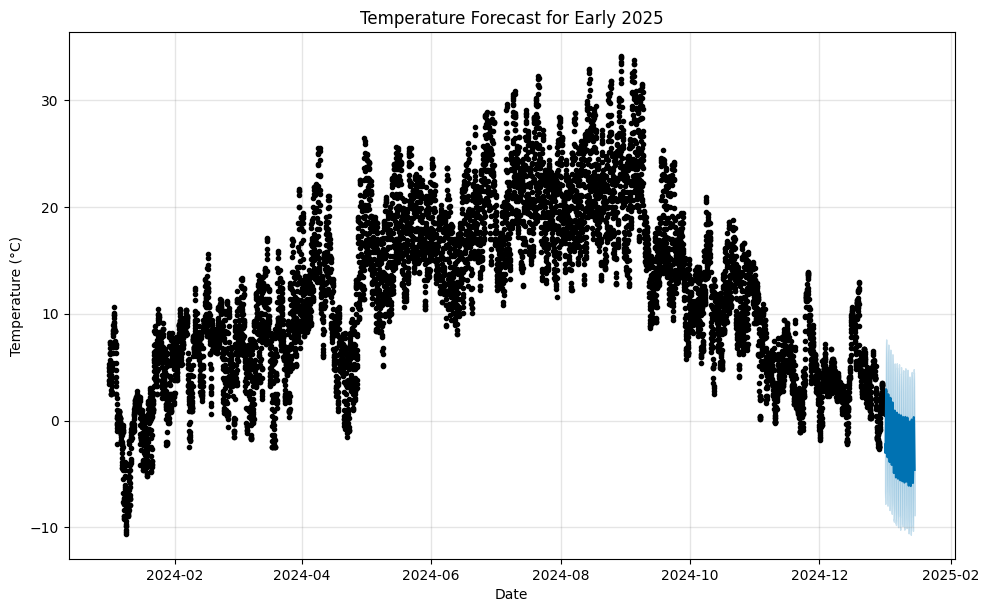

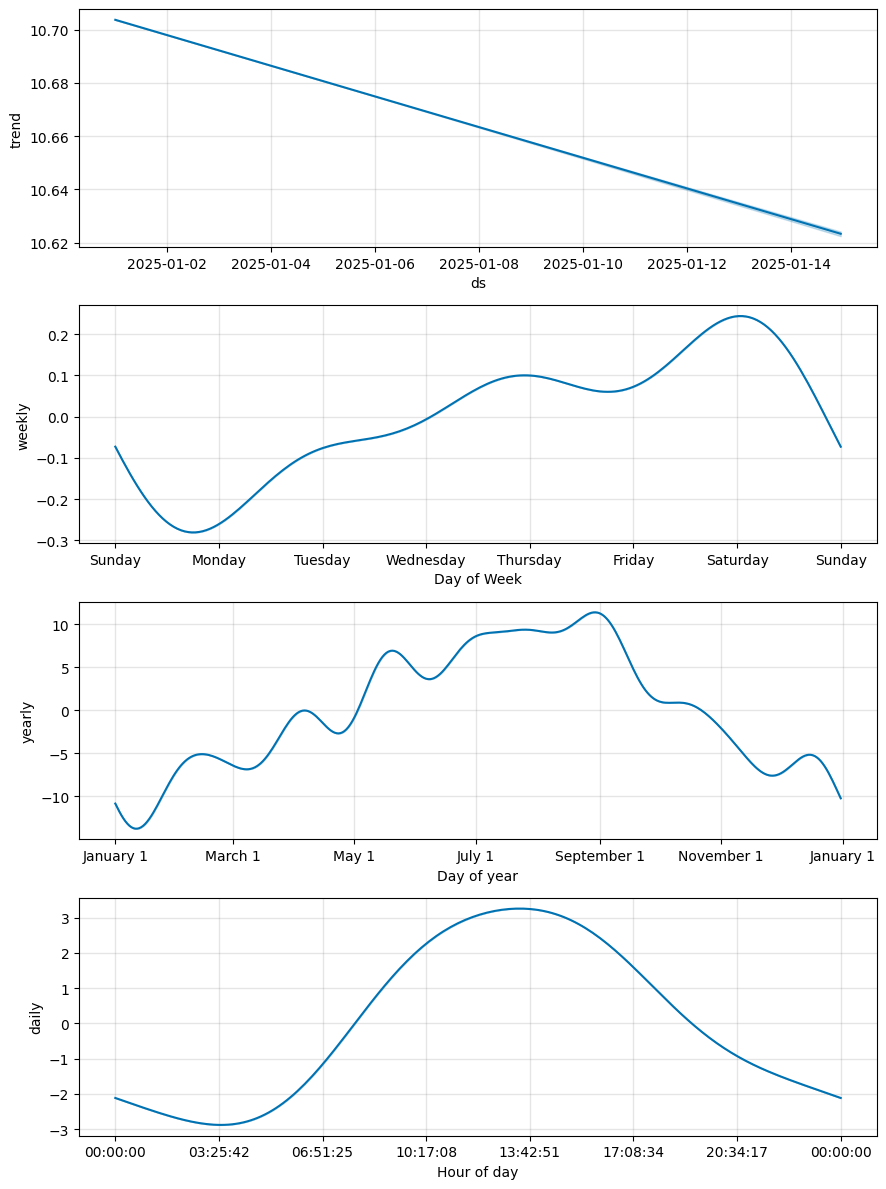

In [7]:
import matplotlib.pyplot as plt

# Plot the forecast
fig = model.plot(forecast)
plt.title('Temperature Forecast for January 2025')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

# Plot the forecast components (trend, weekly, yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

### Calculate MAE and RMSE on Historical Data

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make in-sample predictions on the historical data
in_sample_forecast = model.predict(prophet_df)

# Merge actual values with predictions
performance_df = pd.merge(prophet_df, in_sample_forecast[['ds', 'yhat']], on='ds')

# Calculate MAE
mae = mean_absolute_error(performance_df['y'], performance_df['yhat'])
print(f"Mean Absolute Error (MAE): {mae:.3f}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(performance_df['y'], performance_df['yhat']))
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

print("\nFirst 5 rows of actual vs predicted values:")
display(performance_df.head())

Mean Absolute Error (MAE): 2.736
Root Mean Squared Error (RMSE): 3.396

First 5 rows of actual vs predicted values:


,ds,y,yhat
0,2024-01-01 00:00:00,4.9,0.054668
1,2024-01-01 01:00:00,5.3,-0.255760
2,2024-01-01 02:00:00,5.0,-0.535596
3,2024-01-01 03:00:00,4.6,-0.723774
4,2024-01-01 04:00:00,4.3,-0.729715


### Visualize Residuals

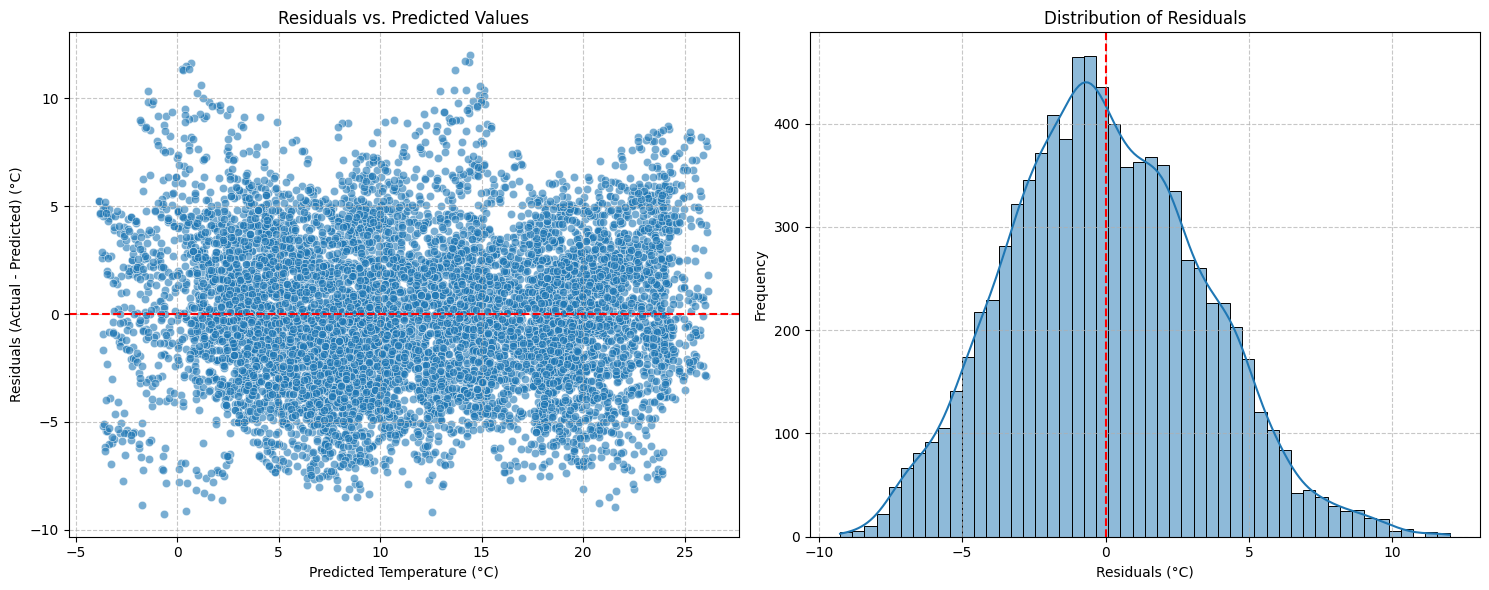

Residuals plot generated successfully.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
performance_df['residuals'] = performance_df['y'] - performance_df['yhat']

plt.figure(figsize=(15, 6))

# Scatter plot of residuals vs. predicted values
plt.subplot(1, 2, 1)
sns.scatterplot(x=performance_df['yhat'], y=performance_df['residuals'], alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Temperature (°C)')
plt.ylabel('Residuals (Actual - Predicted) (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
plt.subplot(1, 2, 2)
sns.histplot(performance_df['residuals'], kde=True, bins=50)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (°C)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Residuals plot generated successfully.")

### Save Forecasted Temperature to CSV

In [12]:
# Select the date and forecasted temperature columns
forecast_to_save = forecast[['ds', 'yhat']]

# Rename the columns for clarity in the CSV
forecast_to_save = forecast_to_save.rename(columns={'ds': 'date', 'yhat': 'forecasted_temperature_celsius'})

# Define the output file path
output_file_path = 'temperature_forecast_jan_2025.csv'

# Save the DataFrame to a CSV file
forecast_to_save.to_csv(output_file_path, index=False)

print(f"Forecasted temperatures saved to {output_file_path}")
display(forecast_to_save.head())

Forecasted temperatures saved to temperature_forecast_jan_2025.csv


,date,forecasted_temperature_celsius
0,2025-01-01 00:00:00,-2.250999
1,2025-01-01 01:00:00,-2.561749
2,2025-01-01 02:00:00,-2.842377
3,2025-01-01 03:00:00,-3.031757
4,2025-01-01 04:00:00,-3.039255


### Convert Hourly Forecast to Daily Forecast

In [15]:
# Ensure the 'date' column is in datetime format
daily_forecast_df = forecast_to_save.copy()
daily_forecast_df['date'] = pd.to_datetime(daily_forecast_df['date'])

# Extract the date part
daily_forecast_df['day'] = daily_forecast_df['date'].dt.date

# Group by day and calculate mean, min, and max temperature
daily_summary = daily_forecast_df.groupby('day')['forecasted_temperature_celsius'].agg(
    mean_temp=('mean'),
    min_temp=('min'),
    max_temp=('max')
).reset_index()

# Rename the 'day' column to 'date' for clarity
daily_summary = daily_summary.rename(columns={'day': 'date'})

print("Daily Temperature Forecast (Mean, Min, Max):")
display(daily_summary.head())
display(daily_summary.tail())

Daily Temperature Forecast (Mean, Min, Max):


,date,mean_temp,min_temp,max_temp
0,2025-01-01,-0.299905,-3.039255,2.924344
1,2025-01-02,-0.748262,-3.437606,2.453213
2,2025-01-03,-1.101820,-3.882943,2.125431
3,2025-01-04,-1.524648,-4.155075,1.692562
4,2025-01-05,-2.245142,-4.915769,0.928921


,date,mean_temp,min_temp,max_temp
25,2025-01-26,1.210650,-1.706128,4.434860
26,2025-01-27,1.690157,-1.386866,4.974940
27,2025-01-28,2.212688,-0.802599,5.477940
28,2025-01-29,2.710292,-0.326450,5.989904
29,2025-01-30,3.096865,0.134543,6.351086


### Save Daily Forecast to CSV

In [16]:
# Define the output file path for the daily forecast
daily_output_file_path = 'daily_temperature_forecast_jan_2025.csv'

# Save the daily_summary DataFrame to a CSV file
daily_summary.to_csv(daily_output_file_path, index=False)

print(f"Daily forecasted temperatures saved to {daily_output_file_path}")

Daily forecasted temperatures saved to daily_temperature_forecast_jan_2025.csv


### Plot Daily Forecasted Mean Temperature

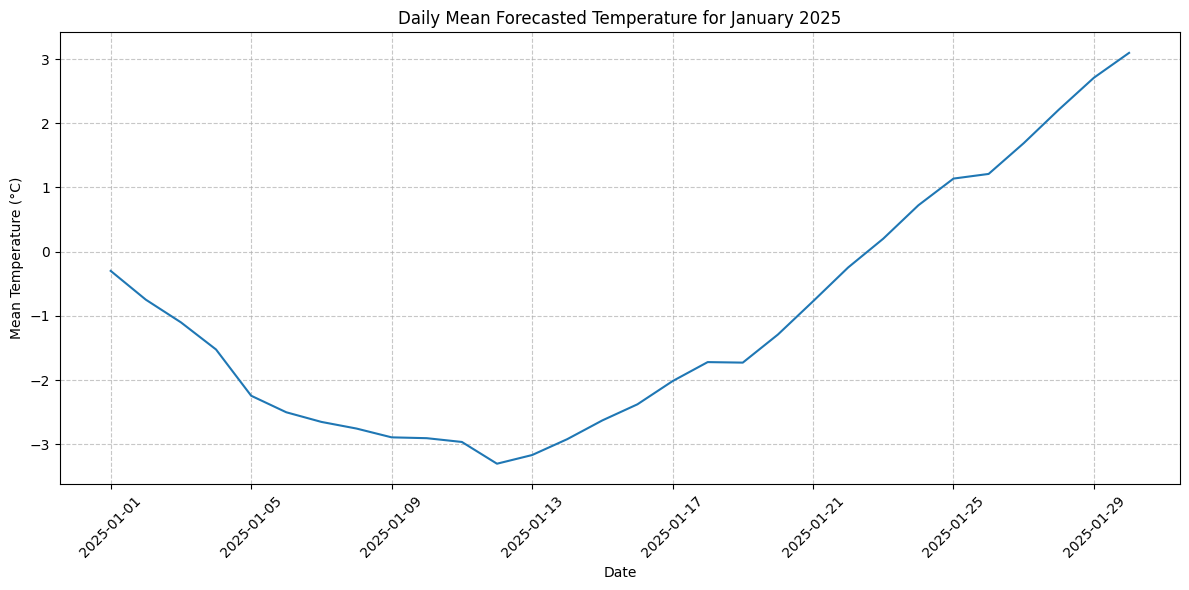

Daily mean forecasted temperature plot generated.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'date' column is in datetime format for plotting
daily_summary['date'] = pd.to_datetime(daily_summary['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='mean_temp', data=daily_summary)
plt.title('Daily Mean Forecasted Temperature for January 2025')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate date labels for better readability
plt.tight_layout()
plt.show()

print("Daily mean forecasted temperature plot generated.")

If you'd like, I can also save this daily forecast to a new CSV file.